<a href="https://colab.research.google.com/github/nawazgs424-oss/Python-Codes/blob/main/Electricity_Demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


Saving April 2022.xlsx to April 2022.xlsx
Saving April 2023.xlsx to April 2023.xlsx
Saving August 2022.xlsx to August 2022.xlsx
Saving August 2023.xlsx to August 2023.xlsx
Saving December 2021.xlsx to December 2021.xlsx
Saving December 2022.xlsx to December 2022.xlsx
Saving December 2023.xlsx to December 2023.xlsx
Saving February 2022.xlsx to February 2022.xlsx
Saving February 2023.xlsx to February 2023.xlsx
Saving January 2022.xlsx to January 2022.xlsx
Saving January 2023.xlsx to January 2023.xlsx
Saving January 2024- June 2025.xlsx to January 2024- June 2025.xlsx
Saving July 2022.xlsx to July 2022.xlsx
Saving July 2023.xlsx to July 2023.xlsx
Saving June 2022.xlsx to June 2022.xlsx
Saving June 2023.xlsx to June 2023.xlsx
Saving March 2022.xlsx to March 2022.xlsx
Saving March 2023.xlsx to March 2023.xlsx
Saving May 2022.xlsx to May 2022.xlsx
Saving May 2023.xlsx to May 2023.xlsx
Saving November 2021.xlsx to November 2021.xlsx
Saving November 2022.xlsx to November 2022.xlsx
Saving Novem

In [ ]:
from google.colab import files

# Opens a file selection dialog
uploaded = files.upload()

# View the uploaded file names
for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')

Saving April 2022.xlsx to April 2022.xlsx
Saving April 2023.xlsx to April 2023.xlsx
Saving August 2022.xlsx to August 2022.xlsx
Saving August 2023.xlsx to August 2023.xlsx
Saving December 2021.xlsx to December 2021.xlsx
Saving December 2022.xlsx to December 2022.xlsx
Saving December 2023.xlsx to December 2023.xlsx
Saving February 2022.xlsx to February 2022.xlsx
Saving February 2023.xlsx to February 2023.xlsx
Saving January 2022.xlsx to January 2022.xlsx
Saving January 2023.xlsx to January 2023.xlsx
Saving January 2024- June 2025.xlsx to January 2024- June 2025.xlsx
Saving July 2022.xlsx to July 2022.xlsx
Saving July 2023.xlsx to July 2023.xlsx
Saving June 2022.xlsx to June 2022.xlsx
Saving June 2023.xlsx to June 2023.xlsx
Saving March 2022.xlsx to March 2022.xlsx
Saving March 2023.xlsx to March 2023.xlsx
Saving May 2022.xlsx to May 2022.xlsx
Saving May 2023.xlsx to May 2023.xlsx
Saving November 2021.xlsx to November 2021.xlsx
Saving November 2022.xlsx to November 2022.xlsx
Saving Novem

Found 29 Excel files to merge.
Using Timestamp Column: 'Timestamp'
Analyzing Time Series Variable: 'Demand (MW)'


/tmp/ipykernel_442/2832400086.py:70: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  combined_df[target_col] = combined_df[target_col].interpolate(method='linear')


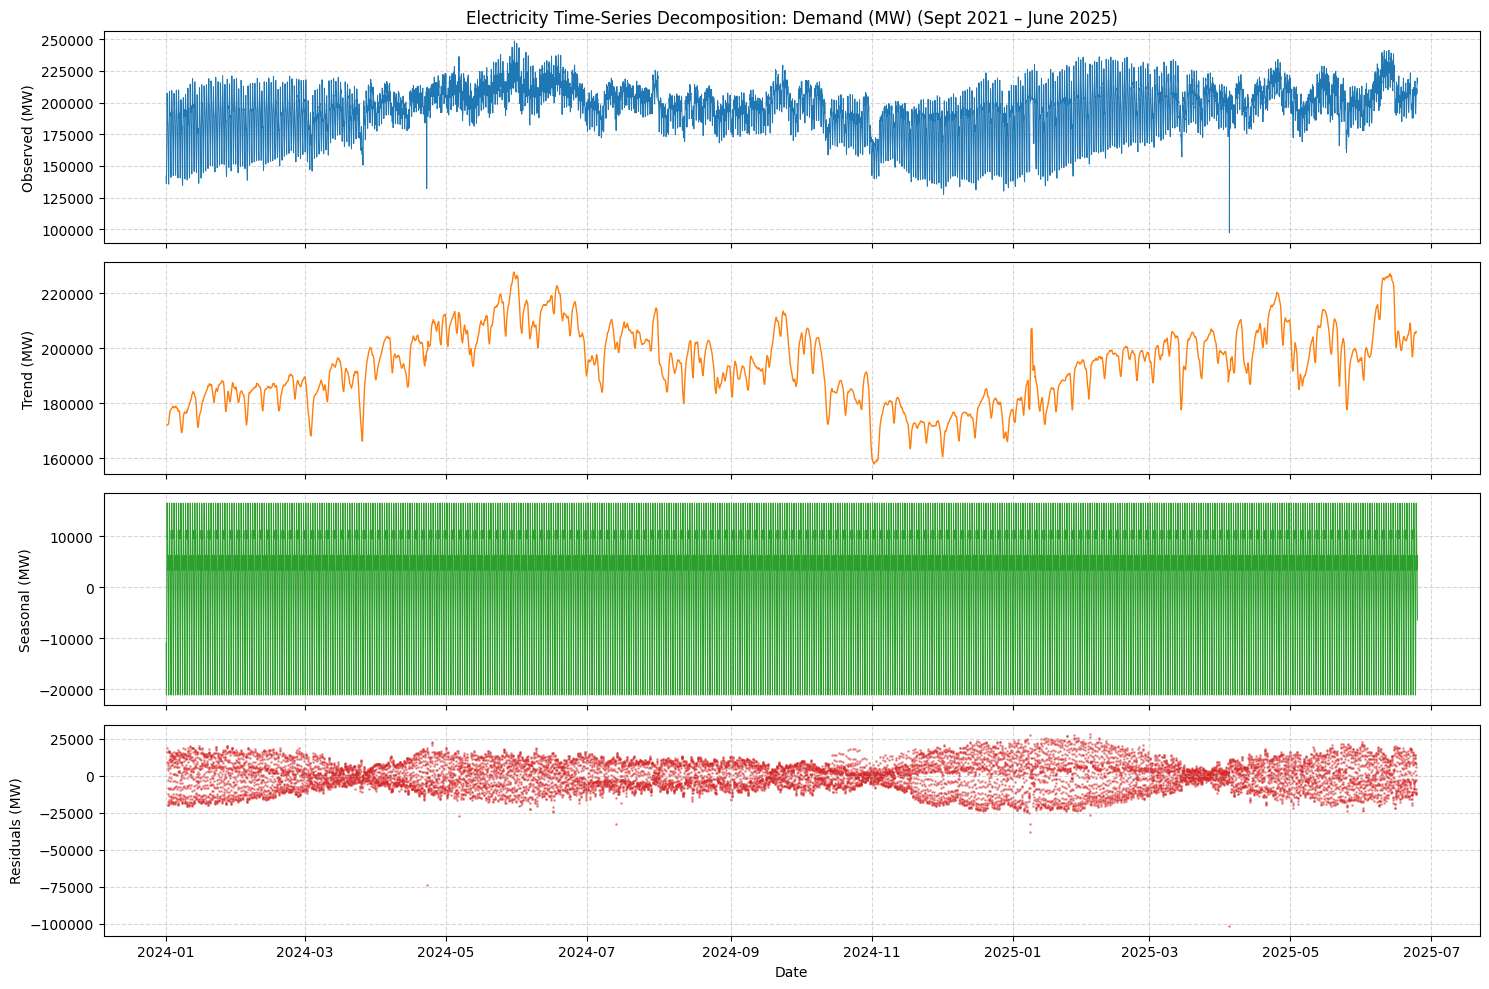

In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ---------------------------------------------------------
# Step 1: Load and Combine All Monthly Excel Files
# ---------------------------------------------------------
file_list = glob.glob("*.xlsx")
print(f"Found {len(file_list)} Excel files to merge.")

if not file_list:
    raise FileNotFoundError("No .xlsx files found in the current directory.")

df_list = []
for file in file_list:
    try:
        temp_df = pd.read_excel(file)

        # Convert all column names to string first before applying .str accessor
        temp_df.columns = [str(col).strip() for col in temp_df.columns]

        df_list.append(temp_df)
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Combine all monthly data into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

# ---------------------------------------------------------
# Step 2: Datetime Processing and Preprocessing
# ---------------------------------------------------------
# Identify date/timestamp column dynamically
time_col = None
for col in combined_df.columns:
    if any(k in col.lower() for k in ['time', 'date', 'datetime', 'timestamp']):
        time_col = col
        break

if time_col is None:
    time_col = combined_df.columns[0]

print(f"Using Timestamp Column: '{time_col}'")

# Use format='mixed' and dayfirst=True to handle varying date formats (e.g. DD-MM-YYYY vs MM-DD-YYYY)
combined_df[time_col] = pd.to_datetime(
    combined_df[time_col],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Set index and sort
combined_df.set_index(time_col, inplace=True)
combined_df = combined_df.sort_index()

# Remove duplicate hourly entries
combined_df = combined_df[~combined_df.index.duplicated(keep='first')]

# Enforce strict 1-hour interval frequency
combined_df = combined_df.asfreq('h')

# Select target variable (first numeric column)
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
target_col = numeric_cols[0] if len(numeric_cols) > 0 else combined_df.columns[0]
print(f"Analyzing Time Series Variable: '{target_col}'")

# Interpolate short missing gaps to ensure continuous values
combined_df[target_col] = combined_df[target_col].interpolate(method='linear')

# ---------------------------------------------------------
# Step 3: Seasonal Decomposition (Daily 24-Hour Period)
# ---------------------------------------------------------
decomp = seasonal_decompose(
    combined_df[target_col],
    model='additive',
    period=24
)

# ---------------------------------------------------------
# Step 4: Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# 1. Observed Data
axes[0].plot(combined_df.index, combined_df[target_col], color='#1f77b4', linewidth=0.7)
axes[0].set_ylabel('Observed (MW)')
axes[0].set_title(f'Electricity Time-Series Decomposition: {target_col} (Sept 2021 – June 2025)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Trend
axes[1].plot(combined_df.index, decomp.trend, color='#ff7f0e', linewidth=1)
axes[1].set_ylabel('Trend (MW)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Daily Seasonal Pattern
axes[2].plot(combined_df.index, decomp.seasonal, color='#2ca02c', linewidth=0.7)
axes[2].set_ylabel('Seasonal (MW)')
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. Residual Noise
axes[3].scatter(combined_df.index, decomp.resid, color='#d62728', s=1, alpha=0.4)
axes[3].set_ylabel('Residuals (MW)')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

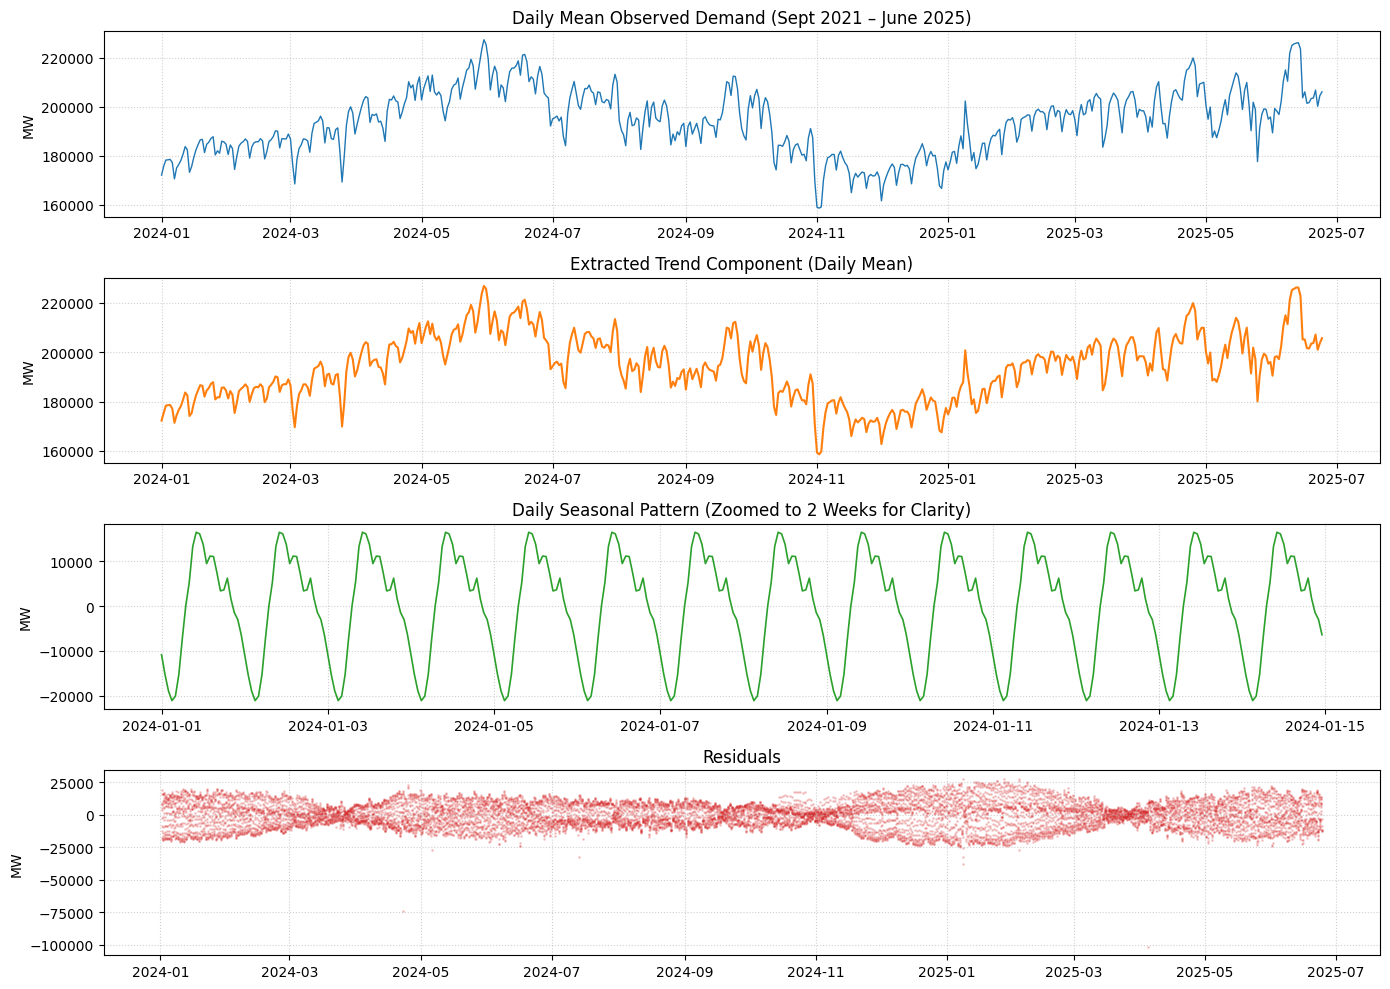

In [ ]:
import matplotlib.pyplot as plt

# Resample observed and trend data to daily averages for clear multi-year plotting
daily_df = combined_df[target_col].resample('D').mean()
daily_trend = decomp.trend.resample('D').mean()

# Select a 14-day sample window to clearly showcase the daily 24-hour seasonal shape
seasonal_sample = decomp.seasonal.dropna().iloc[:24*14]

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# 1. Daily Average Observed Series
axes[0].plot(daily_df.index, daily_df, color='#1f77b4', linewidth=1)
axes[0].set_title('Daily Mean Observed Demand (Sept 2021 – June 2025)')
axes[0].set_ylabel('MW')

# 2. Long-Term Trend
axes[1].plot(daily_trend.index, daily_trend, color='#ff7f0e', linewidth=1.5)
axes[1].set_title('Extracted Trend Component (Daily Mean)')
axes[1].set_ylabel('MW')

# 3. Zoomed 14-Day Seasonal Pattern
axes[2].plot(seasonal_sample.index, seasonal_sample, color='#2ca02c', linewidth=1.2)
axes[2].set_title('Daily Seasonal Pattern (Zoomed to 2 Weeks for Clarity)')
axes[2].set_ylabel('MW')

# 4. Residuals
axes[3].scatter(decomp.resid.index, decomp.resid, color='#d62728', s=1, alpha=0.2)
axes[3].set_title('Residuals')
axes[3].set_ylabel('MW')

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Final plots


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create 4 stacked subplots with shared X-axis
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=(
        f'Observed: {target_col}',
        'Trend Component (Long-Term)',
        'Daily Seasonal Component (24-Hour Cycle)',
        'Residuals (Unexplained Noise)'
    )
)

# 1. Observed
fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df[target_col], name='Observed', line=dict(color='#1f77b4', width=1)), row=1, col=1)

# 2. Trend
fig.add_trace(go.Scatter(x=combined_df.index, y=decomp.trend, name='Trend', line=dict(color='#ff7f0e', width=1.5)), row=2, col=1)

# 3. Seasonal
fig.add_trace(go.Scatter(x=combined_df.index, y=decomp.seasonal, name='Seasonal', line=dict(color='#2ca02c', width=1)), row=3, col=1)

# 4. Residuals
fig.add_trace(go.Scatter(x=combined_df.index, y=decomp.resid, name='Residuals', mode='markers', marker=dict(color='#d62728', size=2, opacity=0.4)), row=4, col=1)

fig.update_layout(
    height=900,
    title_text=f'Interactive Time-Series Decomposition: {target_col}',
    showlegend=False,
    hovermode='x unified'
)

fig.show()


1. Aim:

To load, preprocess, and analyze high-resolution hourly electricity demand and generation data from India (September 2021 – June 2025) using additive classical time-series decomposition to isolate the underlying Trend, Seasonal, and Residual components.

2. Observation:

Raw Observed Series (Y t):
 Shows strong intra-day fluctuations alongside distinct annual load variations. High peak-to-trough ratios occur daily, with annual demand peaks occurring during the summer months (April–June).

Trend Component (T t ):
A steady multi-year upward growth curve reflecting structural electrification and demand expansion across India.

Seasonal Component (S t):
 A repeating 24-hour diurnal cycle with two primary peaks: a mid-day solar/cooling peak and an evening residential lighting/appliance peak.

Residual Component (R t):
 Stationarity centered around zero with localized spikes representing unmodeled atmospheric anomalies, unexpected weather shifts, or extreme grid disturbance events.


3. Result:

The hourly dataset was successfully integrated across all monthly files, preprocessed for continuous time frequency (Δt=1 hour), and decomposed into its core components (Y
t
​
 =T
t
​
 +S
t
​
 +R
t
​
 ).
The daily 24-hour seasonal cycle and underlying long-term demand trends were isolated and visualized, demonstrating the suitability of additive decomposition for grid load monitoring and forecasting.

 4.Conclusion:

The time-series analysis of India's hourly electricity data (September 2021 – June 2025) yields three main insights:

Predictable Diurnal Patterns:
 Electricity demand is heavily driven by a recurring 24-hour cycle, featuring dual daily peaks (afternoon cooling/industrial load and evening residential load). This high periodicity makes short-term grid demand highly forecastable using seasonal modeling.

Persistent Growth Trend: Beyond daily and seasonal variations, the underlying trend shows a consistent upward trajectory, reflecting ongoing economic expansion, increasing urbanization, and rising base cooling/heating requirements across India.

Grid Stability & Renewable Integration: The residual component remains tightly bounded around zero during normal operations, confirming that regular daily cycles account for the vast majority of load variance. However, sudden spikes in residuals highlight the impact of unexpected weather anomalies, underscoring the need for flexible ramping capacity and energy storage to integrate variable solar and wind power effectively.